In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
df = pd.read_csv('/content/train.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.shape

(891, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
df_clean = df.copy()

df_clean['Age'] = df_clean['Age'].fillna(
    df_clean['Age'].median()
)

df_clean['Embarked'] = df_clean['Embarked'].fillna(
    df_clean['Embarked'].mode()[0]
)

df_clean = df_clean.drop(columns=['Cabin'])

df_clean.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
df_clean.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
df_clean['Survived'].value_counts()

,count
Survived,
0,549
1,342


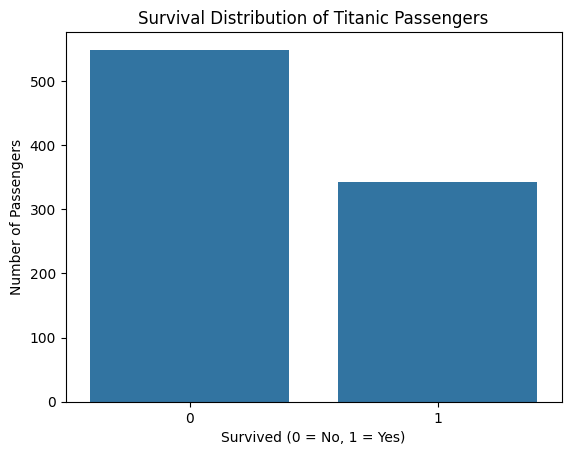

In [12]:
sns.countplot(data=df_clean, x='Survived')
plt.title('Survival Distribution of Titanic Passengers')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.show()

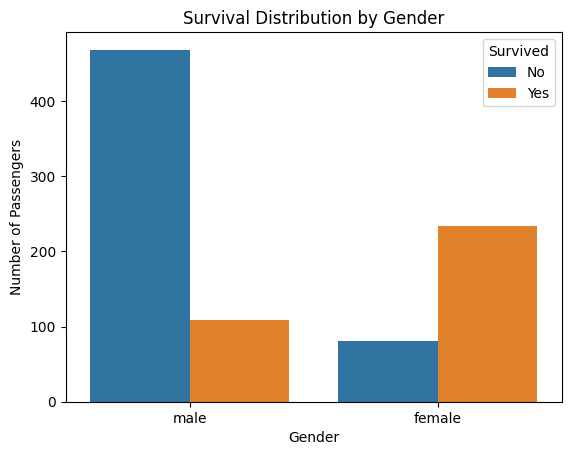

In [13]:
sns.countplot(data=df_clean, x='Sex', hue='Survived')
plt.title('Survival Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

In [14]:
df_clean.groupby('Sex')['Survived'].mean() * 100

,Survived
Sex,
female,74.203822
male,18.890815


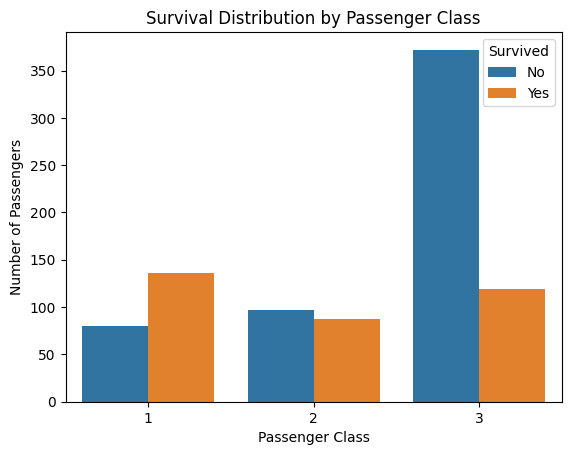

In [15]:
sns.countplot(data=df_clean, x='Pclass', hue='Survived')

plt.title('Survival Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

In [16]:
df_clean.groupby('Pclass')['Survived'].mean() * 100

,Survived
Pclass,
1,62.962963
2,47.282609
3,24.236253


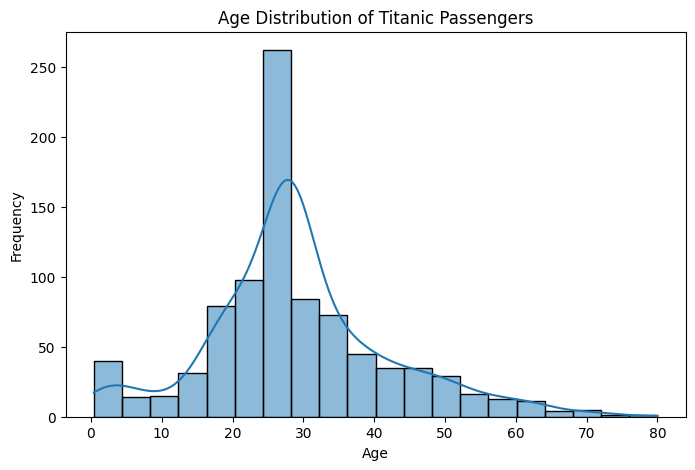

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df_clean, x='Age', bins=20, kde=True)

plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

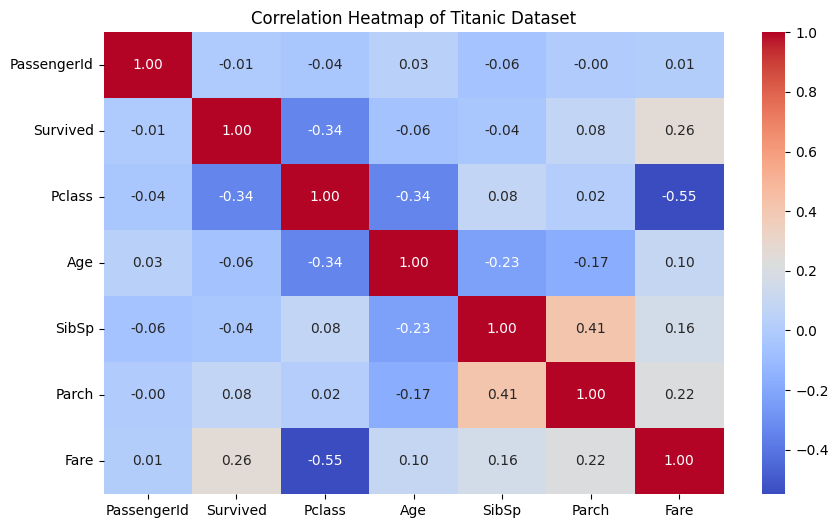

In [18]:
plt.figure(figsize=(10, 6))

correlation = df_clean.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Titanic Dataset')
plt.show()

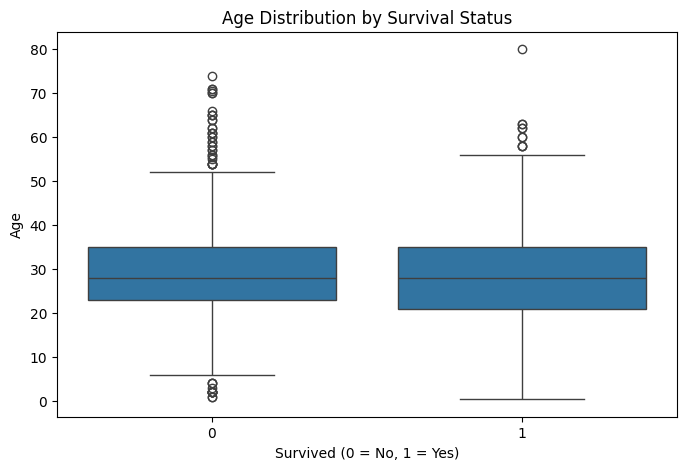

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df_clean, x='Survived', y='Age')

plt.title('Age Distribution by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

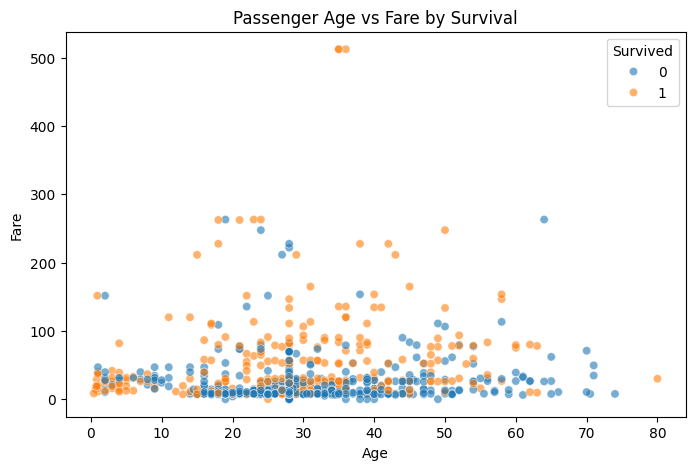

In [20]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x='Age',
    y='Fare',
    hue='Survived',
    alpha=0.6
)

plt.title('Passenger Age vs Fare by Survival')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

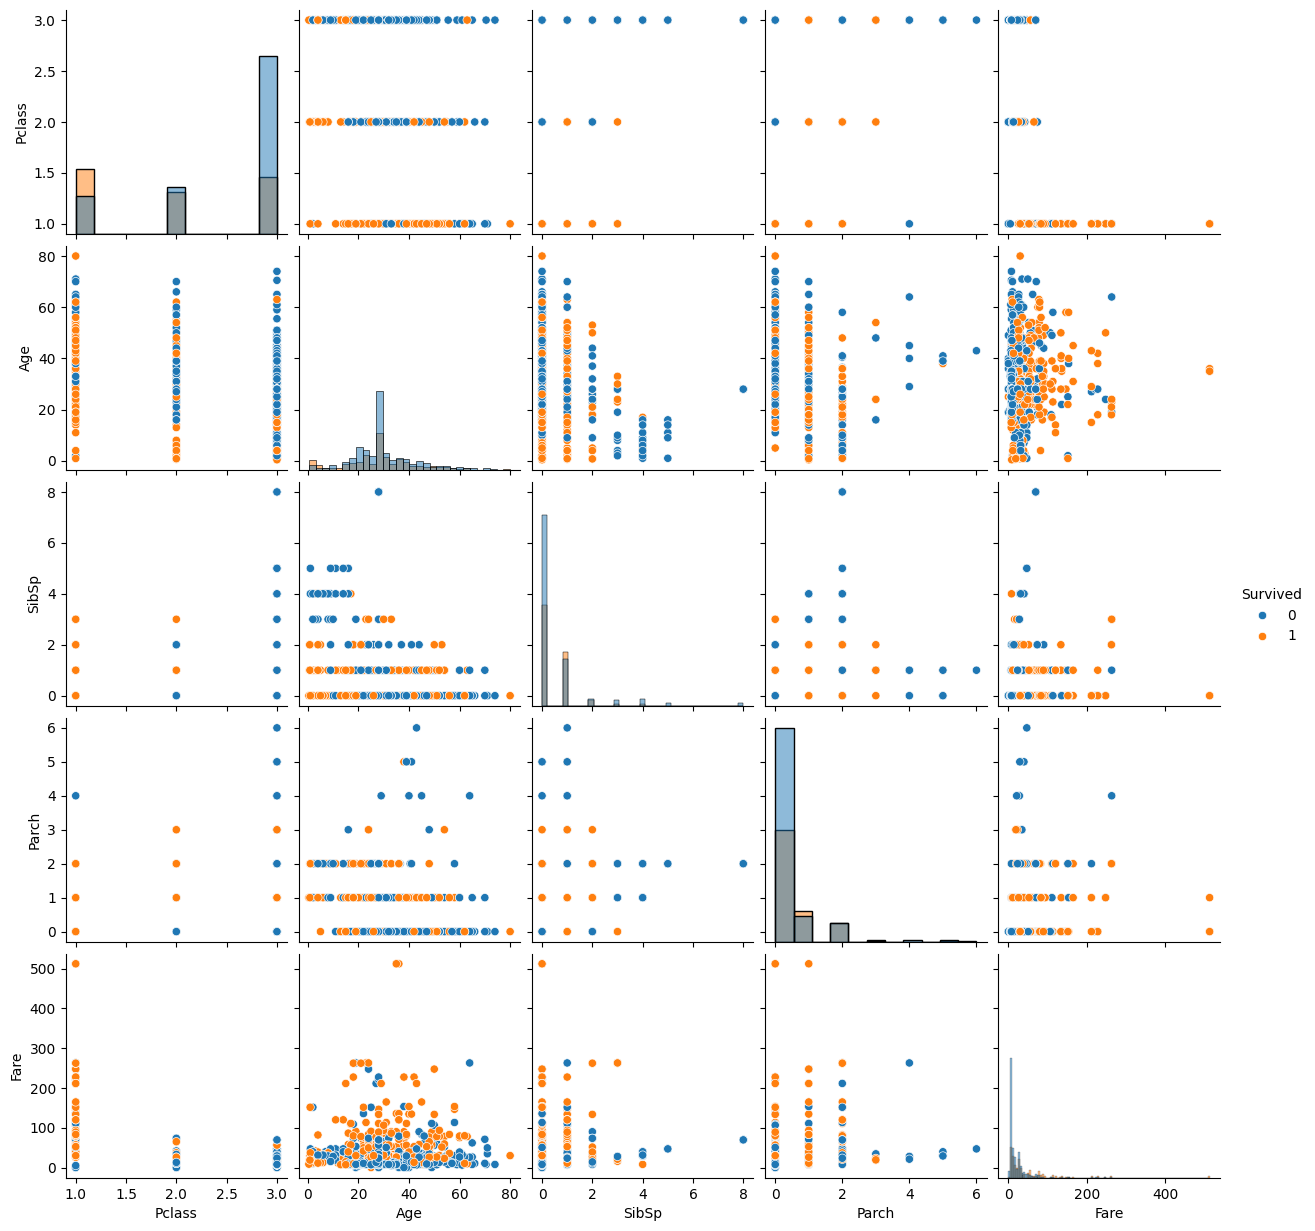

In [21]:
sns.pairplot(
    df_clean[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']],
    hue='Survived',
    diag_kind='hist'
)

plt.show()

In [22]:
print("Overall survival rate:")
print(round(df_clean['Survived'].mean() * 100, 2), "%")

print("\nSurvival rate by gender:")
print((df_clean.groupby('Sex')['Survived'].mean() * 100).round(2))

print("\nSurvival rate by passenger class:")
print((df_clean.groupby('Pclass')['Survived'].mean() * 100).round(2))

Overall survival rate:
38.38 %

Survival rate by gender:
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

Survival rate by passenger class:
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64
